# `teacher_temp_schedule` 은 어떻게 만들어지는가

`main_dino.py` 의 `DINOLoss.__init__` 안에 딱 이 네 줄이 전부다.

```python
self.teacher_temp_schedule = np.concatenate((
    np.linspace(warmup_teacher_temp,
                teacher_temp, warmup_teacher_temp_epochs),
    np.ones(nepochs - warmup_teacher_temp_epochs) * teacher_temp
))
```

즉 **두 조각을 이어 붙인 길이 `nepochs` 의 numpy 배열**이다.

| 조각 | 코드 | 길이 | 값 |
|---|---|---|---|
| ① warmup | `np.linspace(warmup_teacher_temp, teacher_temp, warmup_teacher_temp_epochs)` | `warmup_teacher_temp_epochs` | $\tau_{\text{warm}} \to \tau_t$ 선형 |
| ② 평탄 구간 | `np.ones(nepochs - warmup_teacher_temp_epochs) * teacher_temp` | 나머지 | $\tau_t$ 상수 |

$$
\tau_t[e] =
\begin{cases}
\tau_{\text{warm}} + \dfrac{e}{E_w - 1}\,(\tau_t^{\text{final}} - \tau_{\text{warm}})
  & 0 \le e < E_w \quad\text{(linear warmup, endpoint 포함)}\\[6pt]
\tau_t^{\text{final}} & E_w \le e < E
\end{cases}
$$

그리고 `forward` 에서는 `temp = self.teacher_temp_schedule[epoch]` — **epoch 단위 인덱싱**이다.

왜 warmup을 두는가: **초기 고온은 학습을 불안정하게 만든다.**
온도가 높으면 교사 분포가 평평해져 sharpening이 약해지고, $\tau_t \ge \tau_s$ 로 가면
학습 신호 자체가 사라진다. 그래서 낮은 온도(0.04)에서 출발해 천천히 올린다.

In [1]:
# 필요 패키지: numpy, plotly(+kaleido), torch (main_dino import 용)
import os
import sys

import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots


def _show(fig):
    try:
        from IPython import get_ipython
        if get_ipython() is not None:  # VSCode 셀/Jupyter에서만 렌더링
            fig.show()
    except ImportError:
        pass


try:
    HERE = os.path.dirname(os.path.abspath(__file__))
except NameError:
    HERE = os.getcwd()

DINO_ROOT = "/home/sungwoo/projects/swcho/dino"
np.set_printoptions(precision=4, suppress=True)
print("HERE =", HERE)

HERE = /home/sungwoo/projects/swcho/dino/fm/training/.fm/hints/c49cc950-4968-4ec8-b74b-dff110442907


## 1. 두 조각을 따로 만들어 본다 (논문 권장 설정)

`warmup_teacher_temp=0.04`, `teacher_temp=0.07`, `warmup_teacher_temp_epochs=30`, `nepochs=100`.

In [2]:
WARMUP_TT, TT, WARM_EP, NEPOCHS = 0.04, 0.07, 30, 100

piece1 = np.linspace(WARMUP_TT, TT, WARM_EP)          # ① 선형 warmup
piece2 = np.ones(NEPOCHS - WARM_EP) * TT              # ② 상수 구간

print(f"piece1  len={len(piece1):3d}  head={piece1[:3]}  tail={piece1[-3:]}")
print(f"piece2  len={len(piece2):3d}  head={piece2[:3]}  tail={piece2[-3:]}")

sched = np.concatenate((piece1, piece2))
print(f"concat  len={len(sched):3d}  (nepochs={NEPOCHS})")
assert len(sched) == NEPOCHS, "길이는 항상 정확히 nepochs"
print("epoch  0 / 29 / 30 / 99 →",
      sched[0], sched[WARM_EP - 1], sched[WARM_EP], sched[-1])

piece1  len= 30  head=[0.04   0.041  0.0421]  tail=[0.0679 0.069  0.07  ]
piece2  len= 70  head=[0.07 0.07 0.07]  tail=[0.07 0.07 0.07]
concat  len=100  (nepochs=100)
epoch  0 / 29 / 30 / 99 → 0.04 0.07 0.07 0.07


눈여겨볼 두 가지.

1. `np.linspace` 는 **endpoint 포함**이므로 warmup 마지막 epoch(29)에서 이미 $\tau_t=0.07$ 에 도달한다.
   한 epoch당 증가폭은 $(\tau_t - \tau_{\text{warm}})/(E_w - 1)$ 로, $E_w$ 가 아니라 $E_w-1$ 로 나눈 값이다.
2. `np.linspace(a, b, 0)` 은 **빈 배열**이다 → warmup 0이면 ①이 사라지고 전체가 상수 스케줄이 된다.

In [3]:
print("step (실측) =", np.diff(piece1)[0])
print("step (수식) =", (TT - WARMUP_TT) / (WARM_EP - 1))
print("linspace(0.04, 0.07, 0) =", np.linspace(0.04, 0.07, 0), "-> len", len(np.linspace(0.04, 0.07, 0)))

step (실측) = 0.0010344827586206903
step (수식) = 0.00103448275862069
linspace(0.04, 0.07, 0) = [] -> len 0


## 2. 기본값 vs 논문 권장 — 두 설정 비교

`main_dino.py` 의 argparse 기본값은 `--warmup_teacher_temp 0.04`, `--teacher_temp 0.04`,
`--warmup_teacher_temp_epochs 0` 이다. 즉 **기본으로는 스케줄이 없다** — 100 epoch 전부 0.04 상수.
help 텍스트만 "0.07 이상은 불안정", "warmup 기본 30" 이라고 권장을 언급한다.

In [4]:
def build_schedule(warmup_teacher_temp, teacher_temp, warmup_teacher_temp_epochs, nepochs):
    """main_dino.DINOLoss.__init__ 의 네 줄과 동일."""
    return np.concatenate((
        np.linspace(warmup_teacher_temp, teacher_temp, warmup_teacher_temp_epochs),
        np.ones(nepochs - warmup_teacher_temp_epochs) * teacher_temp,
    ))


CONFIGS = {
    "argparse 기본값 (0.04→0.04, warmup 0)": (0.04, 0.04, 0, NEPOCHS),
    "논문 권장 (0.04→0.07, warmup 30)": (0.04, 0.07, 30, NEPOCHS),
}
SCHEDULES = {name: build_schedule(*cfg) for name, cfg in CONFIGS.items()}

print(f"{'설정':<38} {'len':>4} {'ep0':>7} {'ep15':>7} {'ep29':>7} {'ep30':>7} {'ep99':>7} {'변화?':>6}")
for name, s in SCHEDULES.items():
    print(f"{name:<38} {len(s):>4} {s[0]:>7.4f} {s[15]:>7.4f} {s[29]:>7.4f} "
          f"{s[30]:>7.4f} {s[-1]:>7.4f} {str(s.min() != s.max()):>6}")

설정                                      len     ep0    ep15    ep29    ep30    ep99    변화?
argparse 기본값 (0.04→0.04, warmup 0)      100  0.0400  0.0400  0.0400  0.0400  0.0400  False
논문 권장 (0.04→0.07, warmup 30)            100  0.0400  0.0555  0.0700  0.0700  0.0700   True


## 3. 실제 `DINOLoss` 와 맞춰 본다

`DINOLoss.__init__` 은 프로세스 그룹 없이도 생성된다(`all_reduce` 는 `update_center`, 즉 forward 쪽에만 있다).
그래서 그냥 import 해서 `.teacher_temp_schedule` 을 직접 꺼내 비교할 수 있다.

In [5]:
sys.path.insert(0, DINO_ROOT)
from main_dino import DINOLoss  # noqa: E402

real = DINOLoss(out_dim=16, ncrops=10,
                warmup_teacher_temp=0.04, teacher_temp=0.07,
                warmup_teacher_temp_epochs=30, nepochs=100)
mine = SCHEDULES["논문 권장 (0.04→0.07, warmup 30)"]

print("type =", type(real.teacher_temp_schedule).__name__, "| shape =", real.teacher_temp_schedule.shape)
print("nn.Module buffer 인가? ->", "teacher_temp_schedule" in dict(real.named_buffers()))
print("np.allclose(real, mine) =", np.allclose(real.teacher_temp_schedule, mine))
assert np.allclose(real.teacher_temp_schedule, mine), "손으로 만든 배열과 실제 구현이 달라졌다"
print("max |diff| =", np.abs(real.teacher_temp_schedule - mine).max())

type = ndarray | shape = (100,)
nn.Module buffer 인가? -> False
np.allclose(real, mine) = True
max |diff| = 0.0


배열은 그냥 파이썬 속성(`np.ndarray`)이지 `register_buffer` 가 아니다 —
체크포인트에 저장되지 않고 `__init__` 인자에서 매번 재생성된다.
그래서 **resume 시 `--teacher_temp` 계열 인자를 바꾸면 스케줄도 조용히 바뀐다**.

## 4. epoch 인덱싱 — lr/wd/momentum 스케줄과 해상도가 다르다

`utils.cosine_scheduler` 로 만드는 세 스케줄은 길이가 `epochs * niter_per_ep` 이고
`schedule[it]` (글로벌 iteration)로 조회된다. 반면 교사 온도는 길이가 `nepochs`,
`schedule[epoch]` 으로 조회된다. 같은 학습에서 **해상도가 1251배 차이** 난다.

In [6]:
NITER = 1251  # ImageNet / batch 1024 근사
rows = [
    ("learning rate", "utils.cosine_scheduler", NEPOCHS * NITER, "schedule[it]", "iteration"),
    ("weight decay", "utils.cosine_scheduler", NEPOCHS * NITER, "schedule[it]", "iteration"),
    ("teacher momentum", "utils.cosine_scheduler", NEPOCHS * NITER, "schedule[it]", "iteration"),
    ("teacher temp", "np.linspace + np.ones", NEPOCHS, "schedule[epoch]", "epoch"),
]
print(f"{'스케줄':<18} {'생성':<24} {'len':>9} {'조회':<18} {'해상도':<10}")
for r in rows:
    print(f"{r[0]:<18} {r[1]:<24} {r[2]:>9} {r[3]:<18} {r[4]:<10}")
print(f"\n길이 비 = {NEPOCHS * NITER} / {NEPOCHS} = {NITER}배")
print("→ 온도는 epoch 안에서 계단식으로 '한 번에' 바뀐다 (iteration마다 매끄럽게가 아니라)")

스케줄                생성                             len 조회                 해상도       
learning rate      utils.cosine_scheduler      125100 schedule[it]       iteration 
weight decay       utils.cosine_scheduler      125100 schedule[it]       iteration 
teacher momentum   utils.cosine_scheduler      125100 schedule[it]       iteration 
teacher temp       np.linspace + np.ones          100 schedule[epoch]    epoch     

길이 비 = 125100 / 100 = 1251배
→ 온도는 epoch 안에서 계단식으로 '한 번에' 바뀐다 (iteration마다 매끄럽게가 아니라)


## 5. 온도가 교사 분포에 하는 일

$$
P_t(k) = \frac{\exp\big((z_t(k)-c_k)/\tau_t\big)}{\sum_j \exp\big((z_t(j)-c_j)/\tau_t\big)},
\qquad H(P_t) = -\sum_k P_t(k)\log P_t(k) \in [0,\ \log K]
$$

**고정된 로짓**에 스케줄의 각 epoch 온도만 갈아 끼워 $H(P_t)$ 를 그려 본다.
온도가 올라가면 분포가 평평해지고 엔트로피가 $\log K$ 쪽으로 올라간다.

In [7]:
K = 16
rng = np.random.default_rng(0)
logits = rng.normal(size=(64, K)).astype(np.float64)  # 고정 로짓 (교사 출력 대역)


def softmax(z, tau, axis=-1):
    zz = z / tau
    zz = zz - zz.max(axis=axis, keepdims=True)
    e = np.exp(zz)
    return e / e.sum(axis=axis, keepdims=True)


def entropy(p, axis=-1):
    return -(p * np.log(np.clip(p, 1e-12, None))).sum(axis=axis)


ENT = {name: np.array([entropy(softmax(logits, t)).mean() for t in s])
       for name, s in SCHEDULES.items()}
TOP1 = {name: np.array([softmax(logits, t).max(-1).mean() for t in s])
        for name, s in SCHEDULES.items()}

print(f"log K = {np.log(K):.4f}  (완전 uniform 엔트로피)\n")
print(f"{'설정':<38} {'H@ep0':>7} {'H@ep29':>7} {'H@ep99':>7} {'top1@ep0':>9} {'top1@ep99':>10}")
for name in SCHEDULES:
    h, p = ENT[name], TOP1[name]
    print(f"{name:<38} {h[0]:>7.4f} {h[29]:>7.4f} {h[-1]:>7.4f} {p[0]:>9.4f} {p[-1]:>10.4f}")

log K = 2.7726  (완전 uniform 엔트로피)

설정                                       H@ep0  H@ep29  H@ep99  top1@ep0  top1@ep99
argparse 기본값 (0.04→0.04, warmup 0)      0.1253  0.1253  0.1253    0.9493     0.9493
논문 권장 (0.04→0.07, warmup 30)            0.1253  0.2244  0.2244    0.9493     0.9106


## 6. "초기 고온은 불안정" 을 수치로

교차엔트로피는 $H(P_t, P_s) = H(P_t) + D_{\mathrm{KL}}(P_t \| P_s)$ 로 갈라진다.
학습을 밀어 주는 항은 두 번째, 즉 **교사와 학생 분포의 간격**이다.
학생 온도는 $\tau_s = 0.1$ 로 고정이므로, 같은 로짓에서 $\tau_t$ 를 올리면:

- $\tau_t \ll \tau_s$: 교사가 학생보다 훨씬 날카로움 → sharpening 이 one-hot 쪽으로 강하게 민다.
- $\tau_t = \tau_s$: $P_t = P_s$ → $D_{\mathrm{KL}} = 0$, **학습 신호가 정확히 소멸**.
- $\tau_t > \tau_s$: 부호가 뒤집혀 교사가 학생보다 평평 → 학생을 uniform 쪽으로 끌어당긴다 (붕괴 방향).

초기에는 교사가 거의 랜덤이라 이 신호가 특히 취약하다. 그래서 낮은 온도에서 시작해
표현이 자리 잡은 뒤에 온도를 올린다 — 이것이 warmup 조각 ①의 이유다.

In [8]:
TAU_S = 0.1
taus = np.array([0.02, 0.04, 0.05, 0.07, 0.09, 0.10, 0.12, 0.20])
p_s = softmax(logits, TAU_S)

print(f"tau_s = {TAU_S} (고정), log K = {np.log(K):.4f}\n")
print(f"{'tau_t':>6} {'H(P_t)':>8} {'top1':>7} {'KL(P_t||P_s)':>13} {'신호':>18}")
kls = []
for t in taus:
    p_t = softmax(logits, t)
    kl = (p_t * (np.log(np.clip(p_t, 1e-12, None)) - np.log(np.clip(p_s, 1e-12, None)))).sum(-1).mean()
    kls.append(kl)
    tag = "sharpening (정상)" if t < TAU_S else ("소멸!" if abs(t - TAU_S) < 1e-9 else "uniform 쪽 (위험)")
    print(f"{t:>6.2f} {entropy(p_t).mean():>8.4f} {p_t.max(-1).mean():>7.4f} {kl:>13.6f} {tag:>18}")
kls = np.array(kls)
print(f"\ntau_t=0.04 대비 tau_t=0.09 의 신호 크기 = {kls[4] / kls[1]:.3f}배  (거의 사라진다)")

tau_s = 0.1 (고정), log K = 2.7726

 tau_t   H(P_t)    top1  KL(P_t||P_s)                 신호
  0.02   0.0587  0.9752      0.106960    sharpening (정상)
  0.04   0.1253  0.9493      0.060324    sharpening (정상)
  0.05   0.1582  0.9362      0.042218    sharpening (정상)
  0.07   0.2244  0.9106      0.015778    sharpening (정상)
  0.09   0.2946  0.8851      0.001835    sharpening (정상)
  0.10   0.3315  0.8721      0.000000                소멸!
  0.12   0.4081  0.8458      0.007725     uniform 쪽 (위험)
  0.20   0.7269  0.7397      0.199037     uniform 쪽 (위험)

tau_t=0.04 대비 tau_t=0.09 의 신호 크기 = 0.030배  (거의 사라진다)


표의 요지: $\tau_t$ 를 0.04에서 0.09로만 올려도 신호가 30분의 1 수준(0.030배)으로 줄고, 0.10에서 정확히 0이 된다.
`--teacher_temp` help 가 "0.07 이상은 불안정" 이라고 말하는 이유가 여기 있다 —
0.07은 이미 $\tau_s=0.1$ 에 꽤 가깝다. warmup 없이 처음부터 0.07로 시작하면
교사가 아직 아무것도 모르는 상태에서 약한 신호로 학습하게 된다.

## 7. 그림

- **A** — 두 설정의 `teacher_temp_schedule` (epoch 축). 기본값은 평선, 권장은 30 epoch 램프.
- **B** — 스케줄을 따라간 교사 엔트로피 $H(P_t)$ (고정 로짓).
- **C** — $\tau_t$ 스윕: $H(P_t)$ 와 $\log K$, 그리고 $\tau_s$ 위치.
- **D** — $\tau_t$ 스윕: 학습 신호 $D_{\mathrm{KL}}(P_t\|P_s)$ 가 $\tau_t=\tau_s$ 에서 0으로 떨어진다.

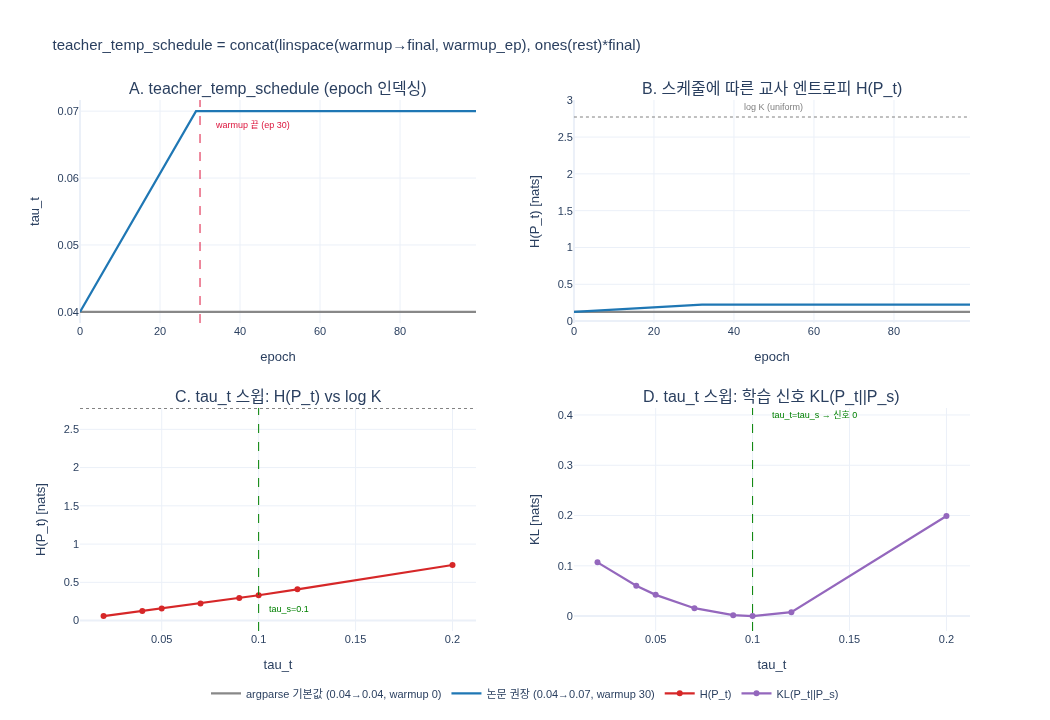

saved: /home/sungwoo/projects/swcho/dino/fm/training/.fm/hints/c49cc950-4968-4ec8-b74b-dff110442907/expy.png 230951 bytes


In [9]:
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=("A. teacher_temp_schedule (epoch 인덱싱)",
                    "B. 스케줄에 따른 교사 엔트로피 H(P_t)",
                    "C. tau_t 스윕: H(P_t) vs log K",
                    "D. tau_t 스윕: 학습 신호 KL(P_t||P_s)"),
    horizontal_spacing=0.11, vertical_spacing=0.16)

epochs = np.arange(NEPOCHS)
colors = ["#888888", "#1f77b4"]
for (name, s), c in zip(SCHEDULES.items(), colors):
    fig.add_trace(go.Scatter(x=epochs, y=s, name=name, mode="lines",
                             line=dict(width=2.2, color=c)), row=1, col=1)
    fig.add_trace(go.Scatter(x=epochs, y=ENT[name], name=name, mode="lines",
                             line=dict(width=2.2, color=c), showlegend=False), row=1, col=2)

fig.add_vline(x=30, line=dict(dash="dash", color="crimson", width=1), row=1, col=1)
fig.add_annotation(x=30, y=0.068, text="warmup 끝 (ep 30)", showarrow=False,
                   xshift=52, font=dict(size=9, color="crimson"), row=1, col=1)
fig.add_hline(y=np.log(K), line=dict(dash="dot", color="gray", width=1), row=1, col=2)
fig.add_annotation(x=50, y=np.log(K), text="log K (uniform)", showarrow=False,
                   yshift=10, font=dict(size=9, color="gray"), row=1, col=2)

fig.add_trace(go.Scatter(x=taus, y=[entropy(softmax(logits, t)).mean() for t in taus],
                         mode="lines+markers", name="H(P_t)",
                         line=dict(width=2.2, color="#d62728")), row=2, col=1)
fig.add_hline(y=np.log(K), line=dict(dash="dot", color="gray", width=1), row=2, col=1)
fig.add_vline(x=TAU_S, line=dict(dash="dash", color="green", width=1), row=2, col=1)
fig.add_annotation(x=TAU_S, y=0.15, text="tau_s=0.1", showarrow=False, xshift=30,
                   font=dict(size=9, color="green"), row=2, col=1)

fig.add_trace(go.Scatter(x=taus, y=kls, mode="lines+markers", name="KL(P_t||P_s)",
                         line=dict(width=2.2, color="#9467bd")), row=2, col=2)
fig.add_vline(x=TAU_S, line=dict(dash="dash", color="green", width=1), row=2, col=2)
fig.add_annotation(x=TAU_S, y=0.4, text="tau_t=tau_s → 신호 0", showarrow=False, xshift=62,
                   font=dict(size=9, color="green"), row=2, col=2)

fig.update_xaxes(title_text="epoch", row=1, col=1)
fig.update_xaxes(title_text="epoch", row=1, col=2)
fig.update_xaxes(title_text="tau_t", row=2, col=1)
fig.update_xaxes(title_text="tau_t", row=2, col=2)
fig.update_yaxes(title_text="tau_t", row=1, col=1)
fig.update_yaxes(title_text="H(P_t) [nats]", row=1, col=2)
fig.update_yaxes(title_text="H(P_t) [nats]", row=2, col=1)
fig.update_yaxes(title_text="KL [nats]", row=2, col=2)
fig.update_layout(height=720, width=1050, template="plotly_white",
                  title_text="teacher_temp_schedule = concat(linspace(warmup→final, warmup_ep), ones(rest)*final)",
                  legend=dict(orientation="h", y=-0.09, x=0.5, xanchor="center"),
                  font=dict(size=11))

_show(fig)
out_png = os.path.join(HERE, "expy.png")
fig.write_image(out_png, scale=2)
print("saved:", out_png, os.path.getsize(out_png), "bytes")